# UAV Propeller Anomaly — Preprocessing

Produces two sets of fixed-size 32×32 feature arrays from raw WAV recordings:
- `mel/` — log-mel spectrograms (32 mel bins × 32 time frames)
- `fft/` — raw FFT magnitude spectrograms downsampled to 32 bins × 32 time frames

See `processing/README.md` for full pipeline documentation.

In [27]:
import math
import numpy as np
import librosa
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

DATASET_DIR = Path('../dataset/Dataset')
OUT_DIR     = Path('.')

SR          = 16_000
WIN_SAMPLES = SR                      # 1 s window
HOP_SAMPLES = math.floor(SR * 0.6)    # 0.6 s hop (40% overlap)

N_FFT       = 512
HOP_LENGTH  = 256
FMIN        = 50
FMAX        = 8_000
N_MELS      = 32
N_FFT_BINS  = 32          # target bins for raw FFT representation

SEED        = 42
TEST_FOLDS  = 1           # 1 fold out of 5 = 20% test
N_SPLITS    = 5

## Step 1 — File discovery and label assignment

In [28]:
# (Binary, class) labels
CLASS_LABELS = {
    'normal':     (0, 0),
    '1_broken':   (1, 1),
    '2_broken':   (1, 2),
    '3_4_broken': (1, 3),
}

records = []  # (path, binary_label, class_label, config, recording_id)

for wav in sorted(DATASET_DIR.rglob('ch1.wav')):
    parts = wav.relative_to(DATASET_DIR).parts  # e.g. ('normal','cw_square','2','ch1.wav')
    class_name = parts[0]
    binary_label, class_label = CLASS_LABELS[class_name]

    if class_name == 'normal':
        config = 'normal'
    elif class_name == '3_4_broken':
        config = parts[2]  # e.g. '0111' under '3_broken'
    else:
        config = parts[1]

    # Unique ID for this recording (used as group in train/test split)
    recording_id = str(wav.parent)

    records.append((wav, binary_label, class_label, config, recording_id))

print(f'Found {len(records)} recordings')
for cls in CLASS_LABELS:
    n = sum(1 for r in records if r[2] == CLASS_LABELS[cls][1])
    print(f'  {cls}: {n}')

Found 293 recordings
  normal: 78
  1_broken: 72
  2_broken: 71
  3_4_broken: 72


## Step 2 — Segmentation

Slice each recording into 1 s windows with 0.5 s hop before feature extraction.

In [29]:
def segment_audio(path):
    """Load WAV and return list of 1-second numpy arrays."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    segments = []
    start = 0
    while start + WIN_SAMPLES <= len(y):
        segments.append(y[start : start + WIN_SAMPLES])
        start += HOP_SAMPLES
    return segments

# Build flat list: (segment_array, binary_label, class_label, config, recording_id)
all_segments = []
for path, bl, cl, config, rec_id in records:
    for seg in segment_audio(path):
        all_segments.append((seg, bl, cl, config, rec_id))

print(f'Total segments: {len(all_segments)}')

Total segments: 30848


## Step 3 — Feature extraction

Compute both representations for every segment.

In [30]:
def to_log_mel(y):
    """1-s audio array → (32, 32) log-mel spectrogram."""
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX,
        power=2.0,
    )
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)  # (32, T)


def to_fft_mag(y):
    """1-s audio array → (32, 32) raw FFT magnitude spectrogram."""
    D = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))  # (257, T)

    # Trim to fmin–fmax frequency range
    freqs = librosa.fft_frequencies(sr=SR, n_fft=N_FFT)
    freq_mask = (freqs >= FMIN) & (freqs <= FMAX)
    D = D[freq_mask, :]  # (~247, T)

    # Downsample frequency axis to N_FFT_BINS by averaging adjacent bins
    n_bins = D.shape[0]
    groups = np.array_split(D, N_FFT_BINS, axis=0)
    D = np.stack([g.mean(axis=0) for g in groups], axis=0)  # (32, T)

    # Convert to dB
    D = librosa.amplitude_to_db(D, ref=np.max)
    return D.astype(np.float32)


def trim_or_pad_time(arr, n_frames=32):
    """Ensure time axis is exactly n_frames (trim or zero-pad)."""
    t = arr.shape[1]
    if t >= n_frames:
        return arr[:, :n_frames]
    return np.pad(arr, ((0, 0), (0, n_frames - t)))


X_mel, X_fft = [], []
y_binary, y_class, groups, strat_keys = [], [], [], []

for seg, bl, cl, config, rec_id in all_segments:
    X_mel.append(trim_or_pad_time(to_log_mel(seg)))
    X_fft.append(trim_or_pad_time(to_fft_mag(seg)))
    y_binary.append(bl)
    y_class.append(cl)
    groups.append(rec_id)
    strat_keys.append(f'{cl}_{config}')  # e.g. '1_0111'

X_mel     = np.stack(X_mel).astype(np.float32)
X_fft     = np.stack(X_fft).astype(np.float32)
y_binary  = np.array(y_binary, dtype=np.int8)
y_class   = np.array(y_class,  dtype=np.int8)
groups    = np.array(groups)
strat_keys = np.array(strat_keys)

print(f'X_mel shape: {X_mel.shape}')   # (N, 32, 32)
print(f'X_fft shape: {X_fft.shape}')

X_mel shape: (30848, 32, 32)
X_fft shape: (30848, 32, 32)


## Step 4 — Train / test split

Split by recording (group) while ensuring every `(class, config)` combination
appears in both splits.

In [31]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Take the first fold's test indices as our held-out test set (= 20%)
train_idx, test_idx = next(sgkf.split(X_mel, strat_keys, groups=groups))

print(f'Train segments: {len(train_idx)}, Test segments: {len(test_idx)}')
print(f'Train recordings: {len(set(groups[train_idx]))}, Test recordings: {len(set(groups[test_idx]))}')

# Verify no recording appears in both splits
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0, 'Leakage detected!'
print('No leakage confirmed.')

# Verify all configs present in test
train_configs = set(strat_keys[train_idx])
test_configs  = set(strat_keys[test_idx])
missing = train_configs - test_configs
if missing:
    print(f'WARNING: configs only in train (not test): {missing}')
else:
    print('All configs represented in test set.')

Train segments: 24801, Test segments: 6047
Train recordings: 236, Test recordings: 57
No leakage confirmed.
All configs represented in test set.


## Step 5 — Normalization

Fit mean/std on train only, apply to both splits.

In [32]:
def normalize(X_train, X_test):
    mean = X_train.mean(axis=0)          # (32, 32)
    std  = X_train.std(axis=0) + 1e-6
    return (X_train - mean) / std, (X_test - mean) / std, mean, std

mel_train, mel_test, mel_mean, mel_std = normalize(X_mel[train_idx],  X_mel[test_idx])
fft_train, fft_test, fft_mean, fft_std = normalize(X_fft[train_idx], X_fft[test_idx])

## Step 6 — Save outputs

In [33]:
def save_split(out_dir, X_train, X_test, y_bin, y_cls, mean, std, train_idx, test_idx):
    out_dir.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        out_dir / 'train.npz',
        X=X_train, y_binary=y_bin[train_idx], y_class=y_cls[train_idx],
    )
    np.savez_compressed(
        out_dir / 'test.npz',
        X=X_test,  y_binary=y_bin[test_idx],  y_class=y_cls[test_idx],
    )
    np.savez_compressed(out_dir / 'stats.npz', mean=mean, std=std)
    print(f'Saved to {out_dir}  train={X_train.shape}  test={X_test.shape}')

save_split(OUT_DIR / 'mel', mel_train, mel_test, y_binary, y_class, mel_mean, mel_std, train_idx, test_idx)
save_split(OUT_DIR / 'fft', fft_train, fft_test, y_binary, y_class, fft_mean, fft_std, train_idx, test_idx)

Saved to mel  train=(24801, 32, 32)  test=(6047, 32, 32)
Saved to fft  train=(24801, 32, 32)  test=(6047, 32, 32)


## Sanity checks

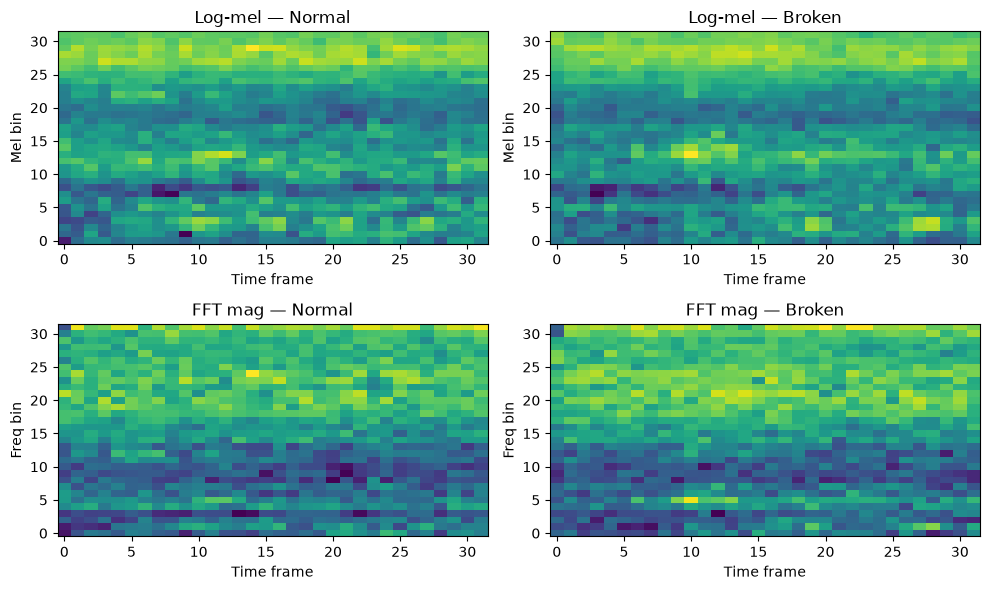

Saved sample_spectrograms.png


In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Pick one normal and one broken segment from train
normal_idx  = np.where(y_binary[train_idx] == 0)[0][0]
broken_idx  = np.where(y_binary[train_idx] == 1)[0][0]

for col, (idx, title) in enumerate([(normal_idx, 'Normal'), (broken_idx, 'Broken')]):
    axes[0, col].imshow(mel_train[idx], origin='lower', aspect='auto')
    axes[0, col].set_title(f'Log-mel — {title}')
    axes[0, col].set_ylabel('Mel bin')

    axes[1, col].imshow(fft_train[idx], origin='lower', aspect='auto')
    axes[1, col].set_title(f'FFT mag — {title}')
    axes[1, col].set_ylabel('Freq bin')

for ax in axes.flat:
    ax.set_xlabel('Time frame')

plt.tight_layout()
plt.savefig(OUT_DIR / 'sample_spectrograms.png', dpi=100)
plt.show()
print('Saved sample_spectrograms.png')

In [35]:
# Class distribution in each split
for split_name, idx in [('Train', train_idx), ('Test', test_idx)]:
    counts = np.bincount(y_class[idx], minlength=4)
    labels = ['normal', '1_broken', '2_broken', '3_4_broken']
    print(f'{split_name}:', {l: int(c) for l, c in zip(labels, counts)})

Train: {'normal': 6773, '1_broken': 6040, '2_broken': 5898, '3_4_broken': 6090}
Test: {'normal': 1728, '1_broken': 1410, '2_broken': 1431, '3_4_broken': 1478}
